# Applying Gaussian Pigment (GPig) Phytoplankton Community Composition Algorithm to OCI data

**Authors:** Anna Windle (NASA, SSAI), Max Danenhower (Bowdoin College), Ali Chase (University of Washington)

Last updated: August 20, 2025

<div class="alert alert-success" role="alert">

The following notebooks are **prerequisites** for this tutorial.

- Learn with OCI: [Data Access][oci-data-access]

</div>

<div class="alert alert-info" role="alert">

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA ocean color data. 

</div>

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_data_access/

## Summary

This notebook applies the inversion algorithm described in [Chase et al., 2017][Chase-et-al] to estimate phytoplankton pigment concentrations from PACE OCI Rrs data. This algorithm, called Gaussian Pigment (GPig), is currently being implemented in OBPG's OCSSW software. This work was originally [developed in MatLab](https://github.com/alisonpchase/Rrs_inversion_pigments) by Ali Chase and subsequently [translated to Python](https://github.com/max-danenhower/pace-rrs-inversions-pigments) by Max Danenhower, Charles Stern, and Ali Chase. This tutorial demonstrates how to apply the Python GPig algorithm to Level-2 (L2) and Level-3 Mapped (L3M) PACE OCI data.

[Chase-et-al]: https://doi.org/10.1002/2017JC012859

## Learning Objectives

At the end of this notebook you will know:

- How to use a packaged Python project 
- How to run the GPig Algorithm on PACE OCI L2 and L3 data

## Contents

1. [Setup](#1.-Setup)
2. [Run GPig on L2 Data](#2.-Run-GPig-on-L2-Data)
3. [Run GPig on L3M Data](#3.-Run-GPig-on-L3M-Data)

## 1. Setup

The GPig Python code has been packaged to allow it to be easily installed, imported, and reused. We will use pip install to get the current packaged code from Github. You may need to restart the kernel after the installation before continuing.

In [1]:
%pip install git+https://github.com/max-danenhower/pace-rrs-inversions-pigments

/tmp/uv/venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


Next, we'll import all of the packages used in this notebook.

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import earthaccess
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from gpig import L2_utils, L3_utils

crs = ccrs.PlateCarree()

Set (and persist to your home directory on the host, if needed) your Earthdata Login credentials.

In [3]:
auth = earthaccess.login(persist=True)

[back to top](#Contents)

## 2. Run GPig on L2 Data

Let's first download the data using the `L2_utils.load()` function. Let's take a look at the docstring:

In [4]:
?L2_utils.load_data

Running `L2_utils.load_data()` downloads several data files from NASA EarthData:

* Rrs: PACE OCI Level-2 AOP data products 
* Sea surface salinity: JPL SMAP-SSS V5.0 CAP, 8-day running mean, level 3 mapped, sea surface salinity (SSS) product from the NASA Soil Moisture Active Passive (SMAP) observatory 
* Sea surface temperature: Group for High Resolution Sea Surface Temperature (GHRSST) Level 4 sea surface temperature

Let's run `L2_utils.load_data()` to download data collected on May 5, 2025 corresponding to a bounding box off the coast of Washington, U.S.

In [5]:
rrs, sss, sst = L2_utils.load_data(("2025-05-01", "2025-05-01"), (-127, 40, -126, 41))
datatree = xr.open_datatree(rrs[0])
dataset = xr.merge(datatree.to_dict().values())
l2_dataset = dataset.set_coords(("longitude", "latitude"))

You should see 3 new folders in your working directory called `L2_rrs_data`, `sal_data`, and `temp_data`. Let's take a quick look at Rrs at 500 nm:

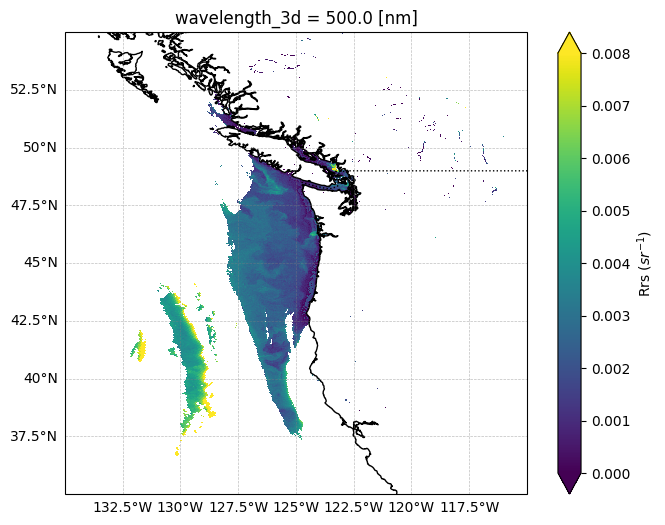

In [6]:
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": crs})

data = l2_dataset["Rrs"].sel({"wavelength_3d": 500})
data.plot(
    x="longitude",
    y="latitude",
    vmin=0,
    vmax=0.008,
    ax=ax,
    cbar_kwargs={"label": "Rrs ($sr^{-1}$)"},
)

ax.set_extent([-135, -115, 35, 55], crs=crs)
ax.coastlines(resolution="10m")
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.gridlines(
    draw_labels=["left", "bottom"],
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--",
)
plt.show()

Now, we can use `L2_utils.estimate_inv_pigments` to calculate phytoplankton pigment concentrations for this data. Let's take a look at the docstring for this function:

In [7]:
?L2_utils.estimate_inv_pigments

You can see that this function accepts a bounding box (bbox) as a parameter. The default is `None` which means it will run the algorithm on every single pixel in the L2 file, which can take a long time. We will supply the `bbox` parameter with the following coordinates:
45 N, 44 S, -125 E, -126 W. 

Let's first see what this bounding box covers:

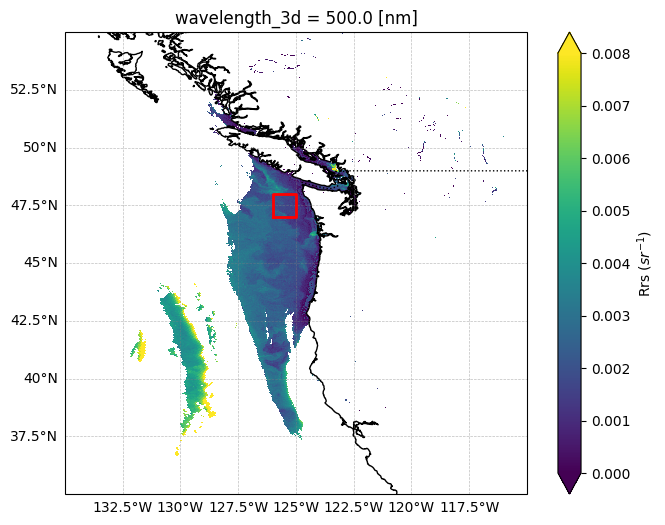

In [8]:
bbox = (-126, 47, -125, 48)

lon_min, lat_min, lon_max, lat_max = bbox
rect_lon = [lon_min, lon_max, lon_max, lon_min, lon_min]
rect_lat = [lat_min, lat_min, lat_max, lat_max, lat_min]
ax.plot(rect_lon, rect_lat, color="red", linewidth=2)

fig

Let's run it. This can take some time depending on bounding box size.

In [9]:
l2_pigments = L2_utils.estimate_inv_pigments(rrs[0], sss, sst, bbox)

L2_rrs_data/PACE_OCI.20250501T201332.L2.OC_AOP.V3_0.nc
-126 47 -125 48


Progress: 1/6042

Progress: 2/6042

Progress: 3/6042

Progress: 4/6042

...

Progress: 6038/6042

Progress: 6039/6042

Progress: 6040/6042

Progress: 6041/6042

Progress: 6042/6042

The inversion provides four pigment variables.

In [10]:
l2_pigments

<xarray.Dataset> Size: 242kB
Dimensions:    (number_of_lines: 106, pixels_per_line: 57)
Coordinates:
    longitude  (number_of_lines, pixels_per_line) float32 24kB -125.9 ... -125.1
    latitude   (number_of_lines, pixels_per_line) float32 24kB 46.81 ... 48.19
Dimensions without coordinates: number_of_lines, pixels_per_line
Data variables:
    chla       (number_of_lines, pixels_per_line) float64 48kB nan nan ... nan
    chlb       (number_of_lines, pixels_per_line) float64 48kB nan nan ... nan
    chlc       (number_of_lines, pixels_per_line) float64 48kB nan nan ... nan
    ppc        (number_of_lines, pixels_per_line) float64 48kB nan nan ... nan

Let's plot the phytoplankton pigment concentrations:

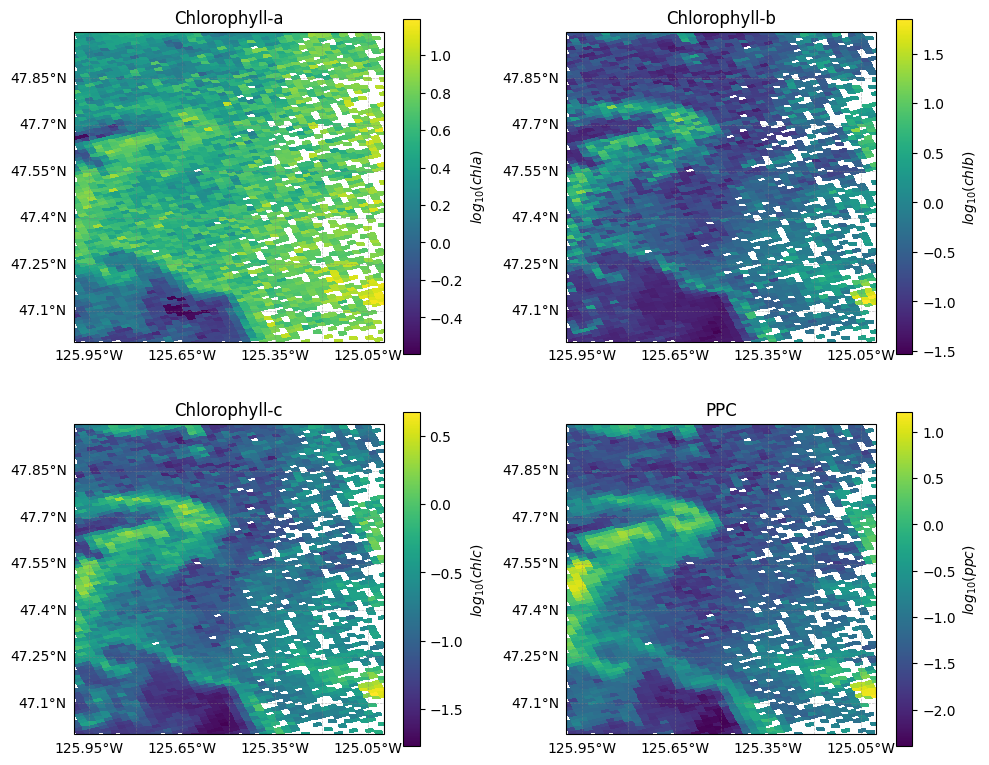

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8), subplot_kw={"projection": crs})

variables = ["chla", "chlb", "chlc", "ppc"]
titles = ["Chlorophyll-a", "Chlorophyll-b", "Chlorophyll-c", "PPC"]
for ax, var, title in zip(axs.flat, variables, titles):
    data = l2_pigments[var]
    lon = l2_pigments["longitude"]
    lat = l2_pigments["latitude"]

    data_log = np.log10(data.where(data > 0))

    im = ax.pcolormesh(lon, lat, data_log, cmap="viridis", shading="auto")

    ax.gridlines(
        draw_labels=["left", "bottom"],
        linewidth=0.5,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlim(bbox[0], bbox[2])
    ax.set_ylim(bbox[1], bbox[3])

    cbar = fig.colorbar(im, ax=ax, orientation="vertical")
    cbar.set_label(f"$log_{{10}}({var})$")

plt.tight_layout()
plt.show()

## 3. Run GPig on L3M Data

We can also run GPig on L3M data. Let's look at the `L3_utils.load_data()` docstring:

In [12]:
?L3_utils.load_data

We'll use this to download 4km L3M Rrs data, global SSS, and global SST data for June 12, 2024:

In [13]:
rrs, sss, sst = L3_utils.load_data(("2024-06-12", "2024-06-12"), "4km")
l3_dataset = xr.open_dataset(rrs[0])

Let's quickly look at L3M Rrs at 500 nm:

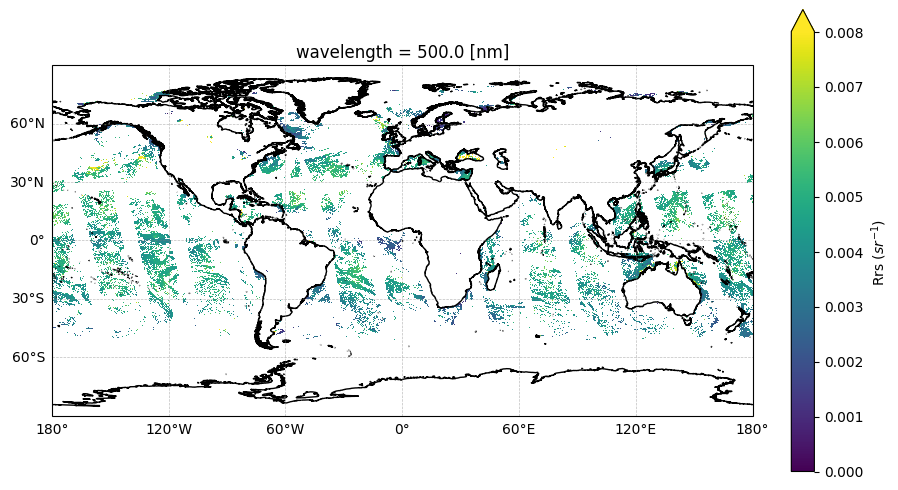

In [14]:
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={"projection": crs})

data = l3_dataset["Rrs"].sel({"wavelength": 500})
data.plot.imshow(
    x="lon",
    y="lat",
    vmin=0,
    vmax=0.008,
    ax=ax,
    cbar_kwargs={"label": r"Rrs ($sr^{-1}$)", "fraction": 0.046},
)

ax.coastlines(resolution="10m")
ax.gridlines(
    draw_labels=["left", "bottom"],
    linewidth=0.5,
    color="gray",
    alpha=0.5,
    linestyle="--",
)

plt.show()

Let's look at what `L3_utils.estimate_inv_pigments` requires as input:

In [15]:
?L3_utils.estimate_inv_pigments

We'll provide the Rrs, SSS, and SST file and input a bounding box corresponding to the coast of Washington, U.S.

Let's take a look at what data this bounding box covers:

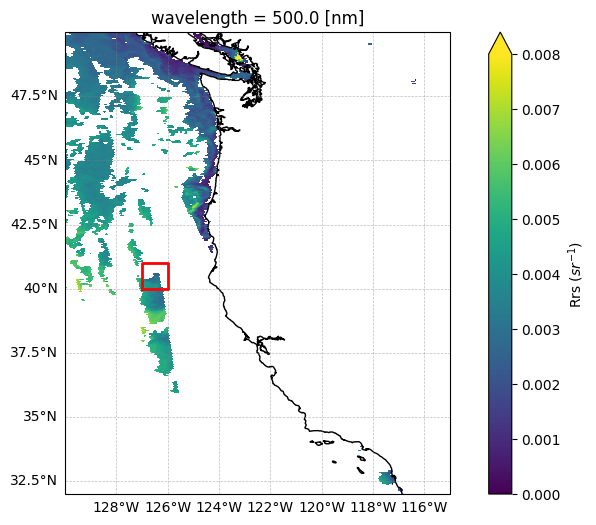

In [16]:
bbox = (-127, 40, -126, 41)

lon_min, lat_min, lon_max, lat_max = bbox
rect_lon = [lon_min, lon_max, lon_max, lon_min, lon_min]
rect_lat = [lat_min, lat_min, lat_max, lat_max, lat_min]
ax.plot(rect_lon, rect_lat, color="red", linewidth=2)

ax.set_extent([-130, -115, 32, 50], crs=crs)

fig

In [17]:
l3_pigments = L3_utils.estimate_inv_pigments(rrs, sss, sst, bbox)

num pixels:  576
Progress: 1/576

Progress: 2/576

Progress: 3/576

Progress: 4/576

Progress: 5/576

...

Progress: 572/576

Progress: 573/576

Progress: 574/576

Progress: 575/576

Progress: 576/576

The inversion provides four pigment variables.

In [18]:
l3_pigments

<xarray.Dataset> Size: 19kB
Dimensions:  (lat: 24, lon: 24)
Coordinates:
  * lat      (lat) float32 96B 40.98 40.94 40.9 40.85 ... 40.15 40.1 40.06 40.02
  * lon      (lon) float32 96B -127.0 -126.9 -126.9 ... -126.1 -126.1 -126.0
Data variables:
    chla     (lat, lon) float64 5kB nan nan nan nan nan ... nan nan nan nan nan
    chlb     (lat, lon) float64 5kB nan nan nan nan nan ... nan nan nan nan nan
    chlc     (lat, lon) float64 5kB nan nan nan nan nan ... nan nan nan nan nan
    ppc      (lat, lon) float64 5kB nan nan nan nan nan ... nan nan nan nan nan

Let's plot all phytoplankton pigment concentrations:

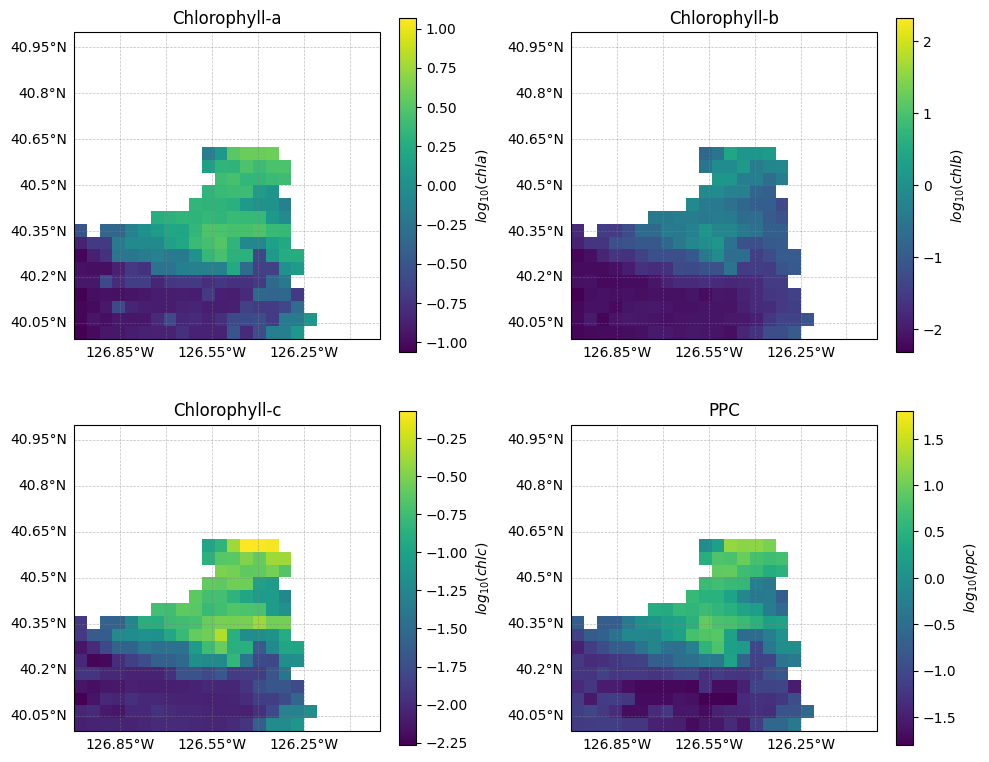

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8), subplot_kw={"projection": crs})

variables = ["chla", "chlb", "chlc", "ppc"]
titles = ["Chlorophyll-a", "Chlorophyll-b", "Chlorophyll-c", "PPC"]
for ax, var, title in zip(axs.flat, variables, titles):

    data = l3_pigments[var]
    data_log = np.log10(data.where(data > 0))

    im = data_log.plot.imshow(
        ax=ax,
        cmap="viridis",
        add_colorbar=False,
    )
    
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.gridlines(
        draw_labels=["left", "bottom"],
        linewidth=0.5,
        color="gray",
        alpha=0.5,
        linestyle="--",
    )

    fig.colorbar(im, ax=ax, orientation="vertical", label=f"$log_{{10}}({var})$")

plt.tight_layout()
plt.show()

[back to top](#Contents)